In [2]:
import pandas as pd

df = pd.read_csv("../data/flipkart_sales.csv")

df.head()


,Order ID,Product Name,Category,Price (INR),Quantity Sold,Total Sales (INR),Order Date,Payment Method,Customer Rating
0,ORD00001,Educational Book,Books,49069.56,2,98139.12,2024-09-12,Debit Card,3.5
1,ORD00002,Jeans,Clothing,12755.85,4,51023.40,2024-12-18,UPI,3.9
2,ORD00003,Face Cream,Beauty,11092.19,4,44368.76,2024-05-18,Debit Card,4.4
3,ORD00004,Smartwatch,Electronics,32657.81,1,32657.81,2024-11-08,Debit Card,3.2
4,ORD00005,Cookware Set,Home & Kitchen,26590.08,3,79770.24,2024-12-27,UPI,3.1


In [3]:
df.columns

Index(['Order ID', 'Product Name', 'Category', 'Price (INR)', 'Quantity Sold',
       'Total Sales (INR)', 'Order Date', 'Payment Method', 'Customer Rating'],
      dtype='object')

In [4]:
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace('(', '')
df.columns = df.columns.str.replace(')', '')

df.columns

Index(['Order_ID', 'Product_Name', 'Category', 'Price_INR', 'Quantity_Sold',
       'Total_Sales_INR', 'Order_Date', 'Payment_Method', 'Customer_Rating'],
      dtype='object')

In [5]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

df['Month'] = df['Order_Date'].dt.month
df['Year'] = df['Order_Date'].dt.year
df['Month_Name'] = df['Order_Date'].dt.strftime('%B')

df.head()

,Order_ID,Product_Name,Category,Price_INR,Quantity_Sold,Total_Sales_INR,Order_Date,Payment_Method,Customer_Rating,Month,Year,Month_Name
0,ORD00001,Educational Book,Books,49069.56,2,98139.12,2024-09-12,Debit Card,3.5,9,2024,September
1,ORD00002,Jeans,Clothing,12755.85,4,51023.40,2024-12-18,UPI,3.9,12,2024,December
2,ORD00003,Face Cream,Beauty,11092.19,4,44368.76,2024-05-18,Debit Card,4.4,5,2024,May
3,ORD00004,Smartwatch,Electronics,32657.81,1,32657.81,2024-11-08,Debit Card,3.2,11,2024,November
4,ORD00005,Cookware Set,Home & Kitchen,26590.08,3,79770.24,2024-12-27,UPI,3.1,12,2024,December


In [7]:
total_revenue = df['Total_Sales_INR'].sum()
print("Total Revenue:", total_revenue)
total_quantity = df['Quantity_Sold'].sum()
print("Total Quantity Sold:", total_quantity)
avg_rating = df['Customer_Rating'].mean()
print("Average Rating:", avg_rating)

Total Revenue: 75213112.74000001
Total Quantity Sold: 3097
Average Rating: 3.0111


<Axes: xlabel='Month_Name'>

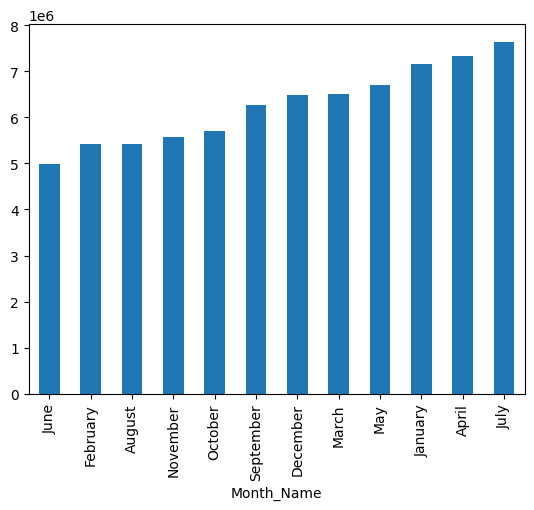

In [8]:
monthly_sales = df.groupby('Month_Name')['Total_Sales_INR'].sum().sort_values()

monthly_sales.plot(kind='bar')

<Axes: xlabel='Category'>

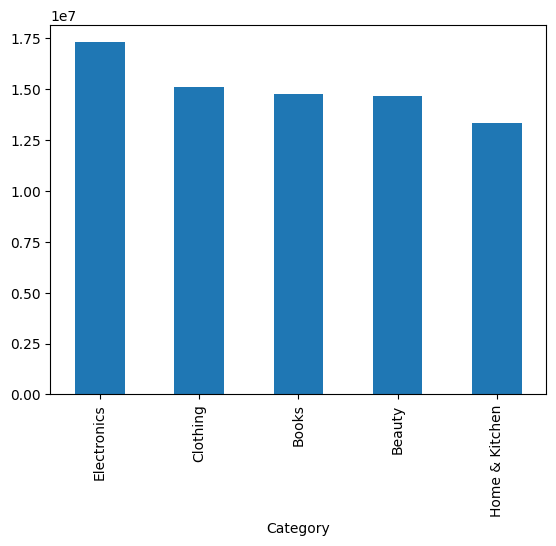

In [9]:
category_sales = df.groupby('Category')['Total_Sales_INR'].sum().sort_values(ascending=False)

category_sales.plot(kind='bar')

<Axes: ylabel='Total_Sales_INR'>

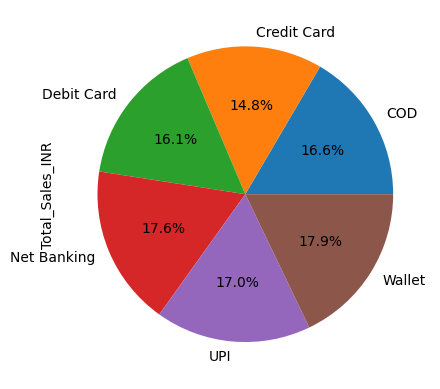

In [10]:
payment_sales = df.groupby('Payment_Method')['Total_Sales_INR'].sum()

payment_sales.plot(kind='pie', autopct='%1.1f%%')

<Axes: xlabel='Product_Name'>

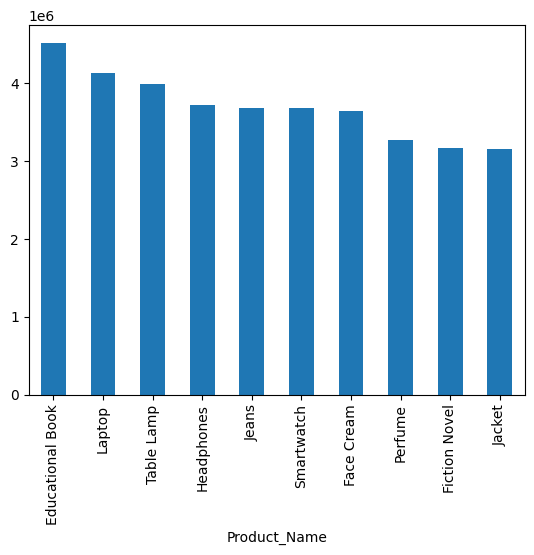

In [11]:
top_products = df.groupby('Product_Name')['Total_Sales_INR'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')

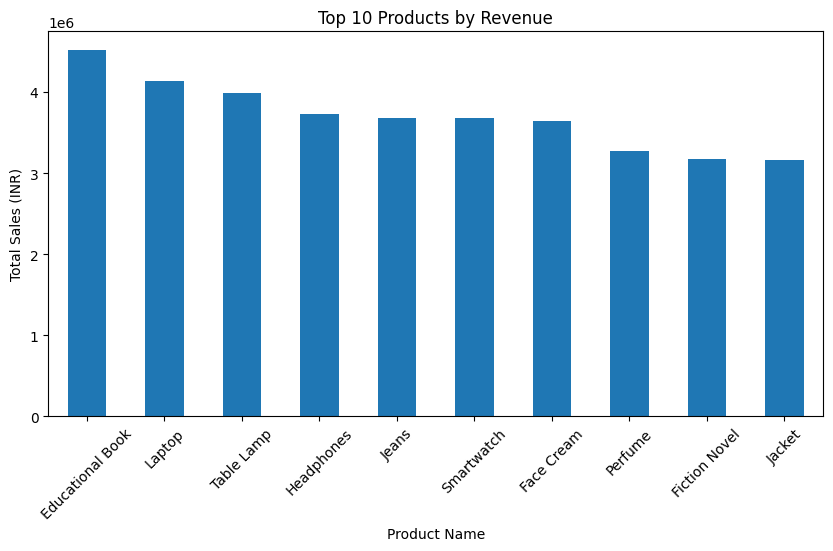

In [12]:
import matplotlib.pyplot as plt

top_products = df.groupby('Product_Name')['Total_Sales_INR'] \
                .sum() \
                .sort_values(ascending=False) \
                .head(10)

plt.figure(figsize=(10,5))
top_products.plot(kind='bar')

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product Name")
plt.ylabel("Total Sales (INR)")
plt.xticks(rotation=45)

plt.show()

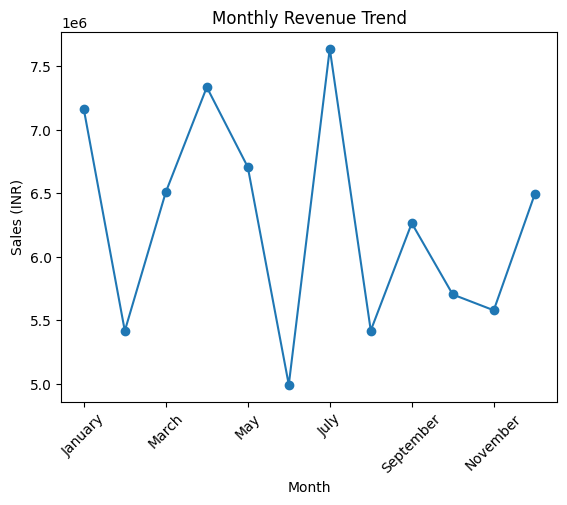

In [13]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_sales = df.groupby('Month_Name')['Total_Sales_INR'].sum()
monthly_sales = monthly_sales.reindex(month_order)

monthly_sales.plot(kind='line', marker='o')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Sales (INR)")
plt.xticks(rotation=45)

plt.show()

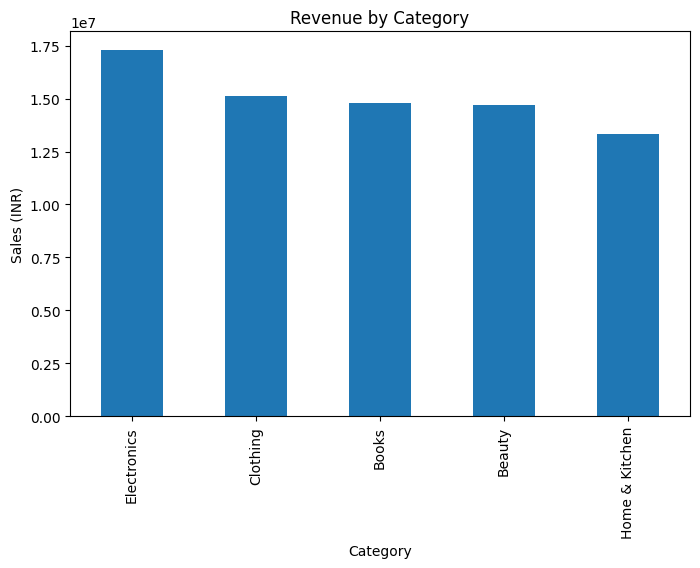

In [14]:
category_sales = df.groupby('Category')['Total_Sales_INR'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Sales (INR)")

plt.show()


In [15]:
total_revenue = df['Total_Sales_INR'].sum()
total_orders = df['Order_ID'].nunique()
avg_order_value = total_revenue / total_orders

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Avg Order Value:", avg_order_value)

Total Revenue: 75213112.74000001
Total Orders: 1000
Avg Order Value: 75213.11274000001


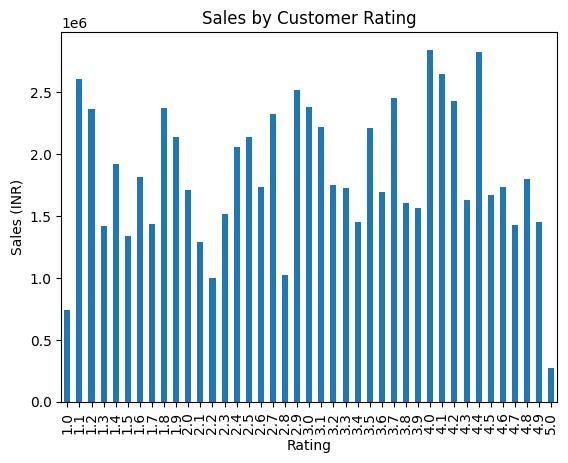

In [16]:
rating_sales = df.groupby('Customer_Rating')['Total_Sales_INR'].sum()

rating_sales.plot(kind='bar')

plt.title("Sales by Customer Rating")
plt.xlabel("Rating")
plt.ylabel("Sales (INR)")

plt.show()

In [17]:
df.to_csv("../outputs/final_sales_data.csv", index=False)